# 1 · Dataset overview

What the pipeline produced, and whether it looks like fire weather before any model sees it.

The dataset is **not** a random sample of Algeria. Every row is a 0.1° cell on one day, and
negatives were drawn from the **same cell** as a positive on a different day. Location is
therefore held constant across the label — so any difference we find here is weather, not
geography.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from importlib import import_module
setup = import_module("00_setup")

d = setup.load_dataset()
FEATURES = setup.FEATURES
print(f"{len(d):,} rows · {len(FEATURES)} features · {d.cell_id.nunique():,} cells")
print(f"years {d.year.min()}–{d.year.max()} · positives {d.label.mean()*100:.1f}%")

121,869 rows · 21 features · 1,423 cells
years 2012–2025 · positives 24.9%


In [2]:
d.groupby(["split", "label"]).size().unstack().rename(columns={0: "no fire", 1: "fire"})

label,no fire,fire
split,,
test,7345,1122
train,76393,28586
val,7780,643


## Class balance is deliberate, and not what deployment looks like

Sampling is 1:3 by construction. The real rate of fire-days among eligible cell-days in
season is far lower — that gap is why **precision measured here is optimistic while recall
is not**. Recall only involves actual fires, so it transfers; precision depends on how many
negatives exist, so it does not.

In [3]:
cells = d.cell_id.nunique()
season_days = 153
years = d.year.nunique()
real_rate = int(d.label.sum()) / (cells * season_days * years)

print(f"sampled positive rate : {d.label.mean()*100:6.2f}%")
print(f"real fire-day rate    : {real_rate*100:6.2f}%   (1 in {1/real_rate:.0f} cell-days)")
print(f"over-representation   : {d.label.mean()/real_rate:6.1f}x")

sampled positive rate :  24.90%
real fire-day rate    :   1.00%   (1 in 100 cell-days)
over-representation   :   25.0x


## Do fire days actually look different?

Same cells on both sides of the label, so this is a clean weather comparison.

In [4]:
cmp = d.groupby("label")[FEATURES].mean().T
cmp.columns = ["no_fire", "fire"]
cmp["change_%"] = (cmp.fire - cmp.no_fire) / cmp.no_fire.abs() * 100
cmp.reindex(cmp["change_%"].abs().sort_values(ascending=False).index).round(2)

,no_fire,fire,change_%
precip_sum,0.82,0.19,-77.23
precip_7d,5.65,2.07,-63.28
precip_30d,24.46,11.94,-51.18
days_since_rain_1mm,16.95,24.25,43.09
dmc,181.76,248.28,36.60
isi,14.50,19.58,35.08
bui,206.45,274.61,33.01
fwi,42.15,55.73,32.24
vpd_max,2.91,3.83,31.57
rh_min,35.39,26.49,-25.13


Every feature should move in the physically correct direction: humidity **down**, vapour
pressure deficit **up**, drought codes **up**, recent rain **down**.

Wind barely moves — and that is correct, not a defect. Wind governs how fast a fire
*spreads* once lit, not whether it ignites. A dataset showing wind as a dominant ignition
signal would be the suspicious one.

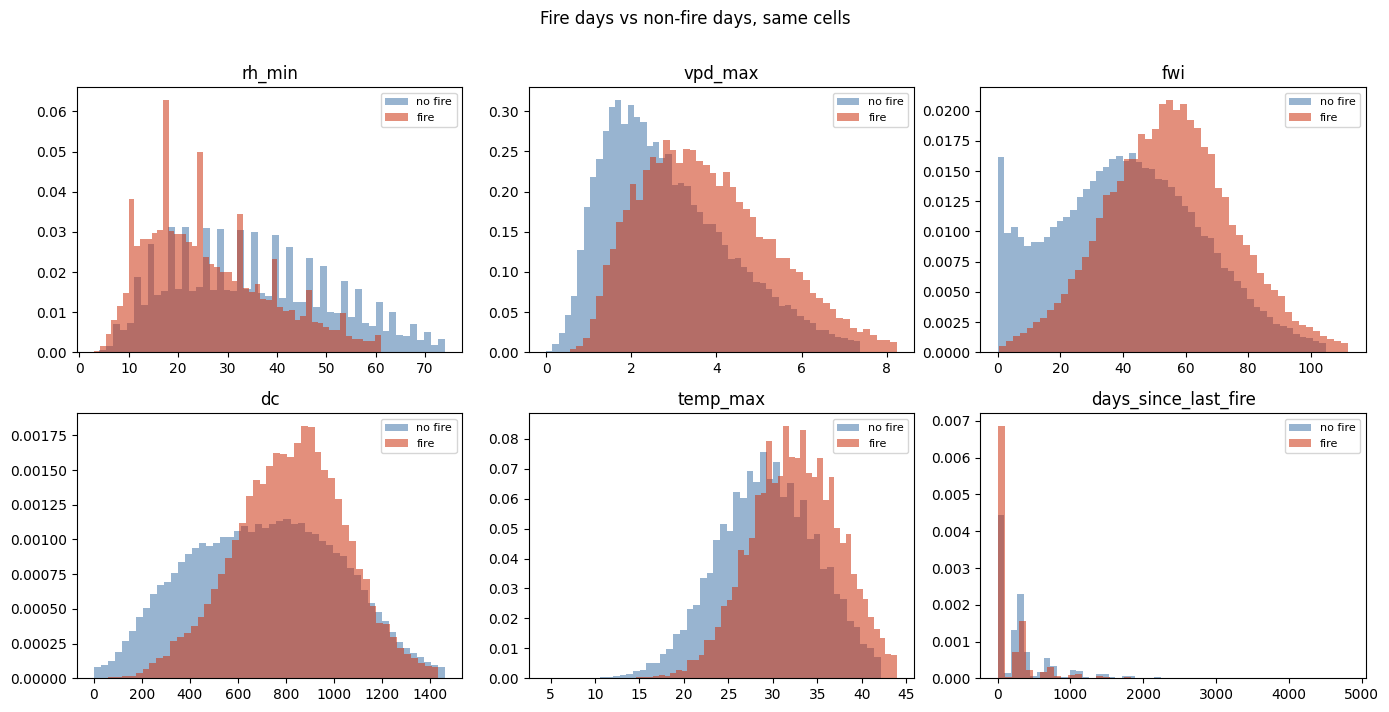

In [5]:
show = ["rh_min", "vpd_max", "fwi", "dc", "temp_max", "days_since_last_fire"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), show):
    for lab, name, colour in [(0, "no fire", "#4477aa"), (1, "fire", "#cc3311")]:
        v = d.loc[d.label == lab, col]
        v = v[v < v.quantile(0.99)]  # trim the sentinel/outlier tail for readability
        ax.hist(v, bins=50, alpha=0.55, label=name, color=colour, density=True)
    ax.set_title(col); ax.legend(fontsize=8)
fig.suptitle("Fire days vs non-fire days, same cells", y=1.01)
fig.tight_layout()

## Fires per season

Year-to-year variation is large — which is exactly why evaluation splits by **year**
rather than randomly.

min      643.0
mean    2168.0
max     4056.0


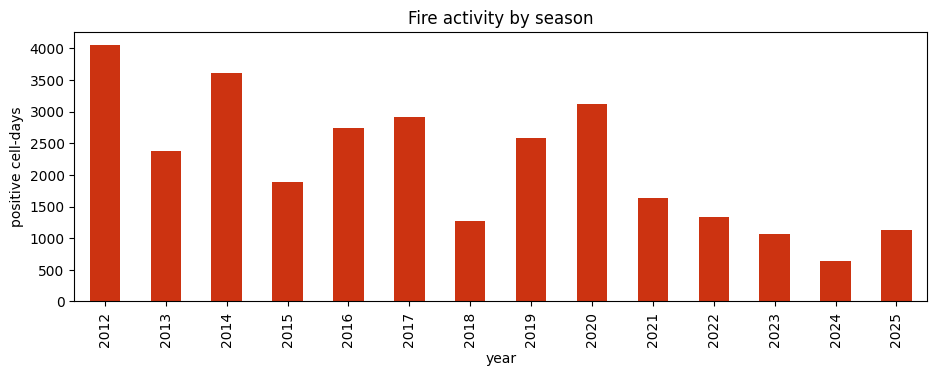

In [6]:
per_year = d[d.label == 1].groupby("year").size()
ax = per_year.plot(kind="bar", figsize=(11, 3.5), color="#cc3311")
ax.set_ylabel("positive cell-days"); ax.set_title("Fire activity by season")
print(per_year.describe()[["min", "mean", "max"]].round(0).to_string())

## Correlation between features

The FWI components are derived from the same weather, so heavy correlation is expected.
It is the reason single-feature importances are hard to read: correlated features share
credit arbitrarily.

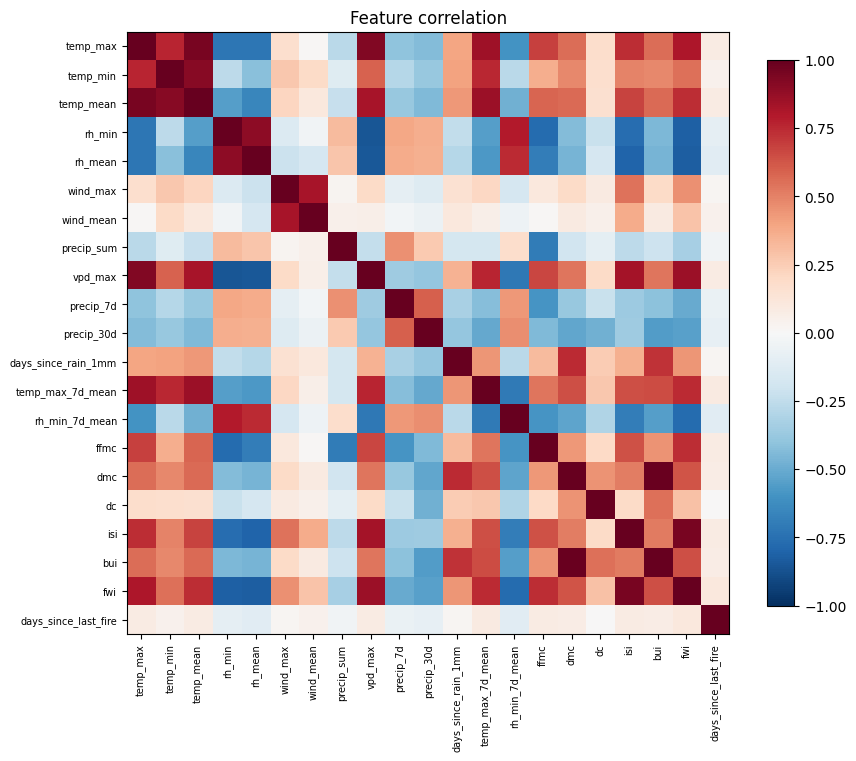

In [7]:
corr = d[FEATURES].corr()
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES))); ax.set_xticklabels(FEATURES, rotation=90, fontsize=7)
ax.set_yticks(range(len(FEATURES))); ax.set_yticklabels(FEATURES, fontsize=7)
fig.colorbar(im, shrink=0.8); ax.set_title("Feature correlation")
fig.tight_layout()